<a href="https://colab.research.google.com/github/duttaprat/BMI_511/blob/main/2026/GLM/NB2_Sequence_Embeddings_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2: Sequence Embeddings and Visualization

**BMI 511 — Spring 2026**
**Instructor:** Pratik Dutta, Ph.D. | Department of Biomedical Informatics, Stony Brook University

---

## Learning objectives

1. Generate **batched DNABERT-2 embeddings** for a collection of sequences.
2. Project 768-d embeddings to 2-d with **PCA**, **t-SNE**, and **UMAP**.
3. Show that biologically distinct sequence classes separate in embedding space *without supervision*.
4. Build a **simple downstream classifier** (logistic regression) on frozen embeddings.

> Runtime: Runtime → Change runtime type → **T4 GPU**.


## 1. Setup

In [10]:
!pip install -q transformers==4.44.2 datasets einops biopython scikit-learn umap-learn

In [11]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

sns.set_style("whitegrid")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


## 2. Build a toy dataset with three sequence classes

To keep the notebook Colab-friendly, we generate **synthetic** sequences from three classes with distinct compositional biases. This mirrors real biological differences (e.g. promoters vs enhancers vs random intergenic DNA) while being fully reproducible.

* **Class 0 — GC-rich, CpG island-like**: typical of CpG islands at promoters.
* **Class 1 — AT-rich with TATA-box motif**: resembles core promoters with TATA signals.
* **Class 2 — random, uniform composition**: baseline intergenic-like sequences.

In Notebook 3 we will swap this synthetic data for a real promoter dataset.

In [12]:
rng = np.random.default_rng(42)

def sample_seq(probs, length=200):
    return ''.join(rng.choice(list("ACGT"), size=length, p=probs))

def make_class(n, probs, motif=None, length=200):
    seqs = []
    for _ in range(n):
        s = sample_seq(probs, length)
        if motif is not None:
            # implant motif at a random position in the middle third
            pos = rng.integers(length // 3, 2 * length // 3)
            s = s[:pos] + motif + s[pos + len(motif):]
        seqs.append(s)
    return seqs

N_PER_CLASS = 60
seqs_gc   = make_class(N_PER_CLASS, probs=[0.15, 0.35, 0.35, 0.15])                        # GC-rich
seqs_tata = make_class(N_PER_CLASS, probs=[0.35, 0.15, 0.15, 0.35], motif="TATAAAAG")      # AT + TATA
seqs_rand = make_class(N_PER_CLASS, probs=[0.25, 0.25, 0.25, 0.25])                        # uniform

sequences = seqs_gc + seqs_tata + seqs_rand
labels    = np.array([0]*N_PER_CLASS + [1]*N_PER_CLASS + [2]*N_PER_CLASS)
label_names = {0: "GC-rich (CpG-like)", 1: "AT-rich + TATA", 2: "random"}

# sanity check: GC content by class
for k, name in label_names.items():
    subset = [s for s, l in zip(sequences, labels) if l == k]
    gc = np.mean([(s.count('G') + s.count('C')) / len(s) for s in subset])
    print(f"class {k} ({name:22s})  n={len(subset):3d}  mean GC = {gc:.2f}")

class 0 (GC-rich (CpG-like)    )  n= 60  mean GC = 0.70
class 1 (AT-rich + TATA        )  n= 60  mean GC = 0.29
class 2 (random                )  n= 60  mean GC = 0.50


## 3. Load DNABERT-2

In [13]:
from transformers import BertModel, BertConfig

MODEL_NAME = "zhihan1996/DNABERT-2-117M"

config = BertConfig.from_pretrained(MODEL_NAME)
model = BertModel.from_pretrained(
    MODEL_NAME,
    config=config,
).to(device)
model.eval()
print("DNABERT-2 loaded.")

Some weights of BertModel were not initialized from the model checkpoint at zhihan1996/DNABERT-2-117M and are newly initialized: ['bert.embeddings.position_embeddings.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attention.self.value.weight', 'bert.encoder.layer.0.intermediate.dense.bias', 'bert.encoder.layer.0.intermediate.dense.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.dense.bias', 'bert.encoder.layer.0.output.dense.weight', 'bert.encoder.layer.1.attention.self.key.bias', 'bert.encoder.layer.1.attention.self.key.weight', 'bert.encoder.layer.1.attention.self.query.bias', 'bert.encoder.layer.1.attention.self.query.weight', 'bert.encoder.layer.1.attention.self.value.b

DNABERT-2 loaded.


## 4. Batched embedding extraction

Embedding one sequence at a time is wasteful. We pad a mini-batch to the longest sequence in the batch and run them together on the GPU.


In [14]:
from tqdm.auto import tqdm

@torch.no_grad()
def embed_batch(seqs, model, tokenizer, device, batch_size=16, pool="mean"):
    """Return an (N, hidden_size) array of sequence embeddings."""
    all_vecs = []
    for i in tqdm(range(0, len(seqs), batch_size), desc="Embedding"):
        batch = seqs[i:i + batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        out = model(**enc)
        hidden = out[0] if isinstance(out, tuple) else out.last_hidden_state   # (B, T, H)
        mask = enc["attention_mask"].unsqueeze(-1).float()                     # (B, T, 1)
        if pool == "mean":
            pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        elif pool == "cls":
            pooled = hidden[:, 0, :]
        else:
            raise ValueError(pool)
        all_vecs.append(pooled.cpu().numpy())
    return np.concatenate(all_vecs, axis=0)

embeddings = embed_batch(sequences, model, tok, device, batch_size=16, pool="mean")
print("Embeddings shape:", embeddings.shape)

Embedding:   0%|          | 0/12 [00:00<?, ?it/s]

Embeddings shape: (180, 768)


## 5. Visualize embeddings in 2D

We try three popular dimensionality-reduction techniques:

* **PCA** — linear, fast, preserves global variance.
* **t-SNE** — non-linear, emphasizes local neighborhoods, good for cluster separation.
* **UMAP** — non-linear, preserves both local and some global structure; typically the best default today.


In [15]:
# Standardize embeddings before PCA (common practice).
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(embeddings)

pca = PCA(n_components=2, random_state=0).fit_transform(X)
tsne = TSNE(n_components=2, perplexity=15, random_state=0, init="pca").fit_transform(X)

import umap
umap_2d = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=0).fit_transform(X)

projections = {"PCA": pca, "t-SNE": tsne, "UMAP": umap_2d}

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


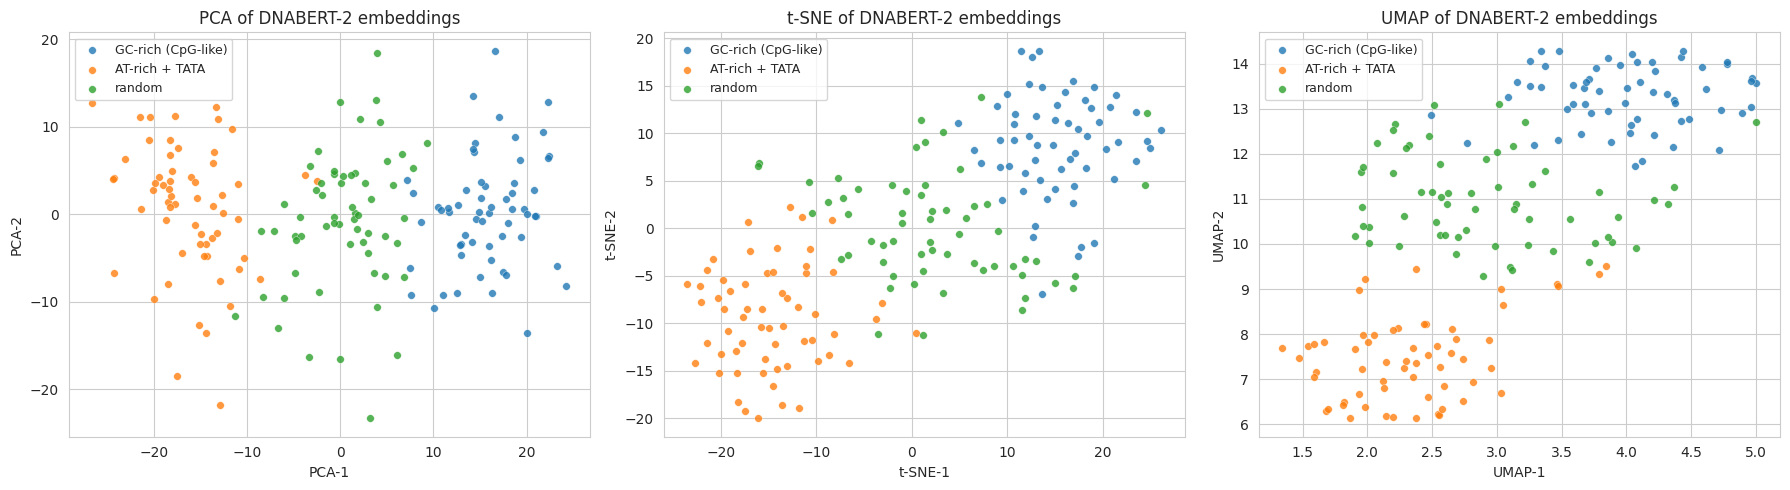

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = {0: "#1f77b4", 1: "#ff7f0e", 2: "#2ca02c"}

for ax, (name, proj) in zip(axes, projections.items()):
    for k, cname in label_names.items():
        mask = labels == k
        ax.scatter(proj[mask, 0], proj[mask, 1], s=30, alpha=0.8,
                   label=cname, color=palette[k], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{name} of DNABERT-2 embeddings")
    ax.set_xlabel(f"{name}-1")
    ax.set_ylabel(f"{name}-2")
    ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()

**What to look for**: despite DNABERT-2 never seeing a single label, the three classes form distinct groups in embedding space. That is the key promise of self-supervised pretraining — the model has discovered composition and motif structure on its own.

## 6. Pairwise similarity heatmap

Cosine similarity between embeddings should be **high within a class** and **low across classes**.


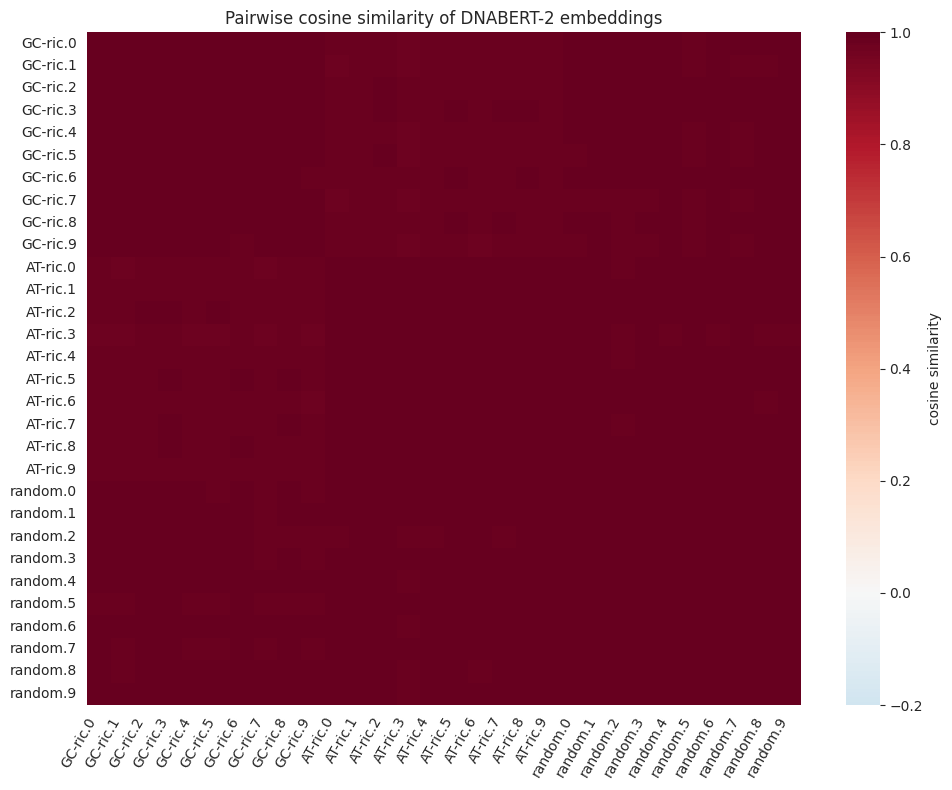

Mean similarity within class : 0.995
Mean similarity across class : 0.991


In [17]:
# Sample 10 sequences per class for a readable heatmap.
sample_idx = np.concatenate([
    np.where(labels == k)[0][:10] for k in [0, 1, 2]
])
sub_emb = embeddings[sample_idx]
sub_lab = labels[sample_idx]
sim = cosine_similarity(sub_emb)

ticks = [f"{label_names[l][:6]}.{i%10}" for i, l in enumerate(sub_lab)]
plt.figure(figsize=(10, 8))
sns.heatmap(sim, xticklabels=ticks, yticklabels=ticks, cmap="RdBu_r", center=0,
            vmin=-0.2, vmax=1.0, cbar_kws={"label": "cosine similarity"})
plt.title("Pairwise cosine similarity of DNABERT-2 embeddings")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Average within-class vs across-class similarity
within, across = [], []
for i in range(len(sub_emb)):
    for j in range(i + 1, len(sub_emb)):
        (within if sub_lab[i] == sub_lab[j] else across).append(sim[i, j])
print(f"Mean similarity within class : {np.mean(within):.3f}")
print(f"Mean similarity across class : {np.mean(across):.3f}")

## 7. Quick downstream classifier on frozen embeddings

An immediate payoff of pretrained embeddings: you can train a tiny classifier on top without touching the transformer weights. This is called **linear probing** or **frozen-feature classification**. It's a great sanity check — if a logistic regression already works, you probably don't need full fine-tuning.


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.3, stratify=labels, random_state=0
)

clf = LogisticRegression(max_iter=2000, C=1.0, multi_class="multinomial").fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"Linear-probe accuracy: {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, target_names=[label_names[k] for k in [0, 1, 2]]))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Linear-probe accuracy: 0.926

                    precision    recall  f1-score   support

GC-rich (CpG-like)       0.85      0.94      0.89        18
    AT-rich + TATA       1.00      1.00      1.00        18
            random       0.94      0.83      0.88        18

          accuracy                           0.93        54
         macro avg       0.93      0.93      0.93        54
      weighted avg       0.93      0.93      0.93        54



## 8. Exercise

Try this yourself:

1. Change `pool="mean"` to `pool="cls"` in `embed_batch` and re-run the projections. Do the clusters change?
2. Increase `N_PER_CLASS` to 200 and re-run. Does linear-probe accuracy go up?
3. Add a **fourth class** — e.g. sequences with a GATA motif (`GATAAG`) implanted into random background — and see if the embeddings can still tell it apart from the other three.

## 9. Recap

* Pretrained gLM embeddings are a **drop-in feature representation** for DNA sequences.
* Projecting to 2D with UMAP / t-SNE typically reveals biologically meaningful structure.
* A small classifier on **frozen embeddings** is often a strong baseline and a great debugging tool before investing GPU time in fine-tuning.

Next: **Notebook 3** will fine-tune DNABERT-2 end-to-end on a real promoter classification dataset.